In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

In [2]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

plt.rcParams.update({
'figure.figsize': (10, 5),
'grid.color': '#dddddd',
'grid.linestyle': '--',
'axes.grid': True,
})

patient_df = pd.read_csv(r'C:\Users\prati\Downloads\Patient_Data.csv')
billing_df = pd.read_csv(r'C:\Users\prati\Downloads\Billing_Data.csv')

In [3]:
print("=== Patient Dataset Summary ===")
patient_df.info()
display(patient_df.head())
display(patient_df.dtypes)
display(patient_df.info())
print("=== Billing Dataset Summary ===")
billing_df.info()
display(billing_df.head())
display(billing_df.dtypes)
display(billing_df.info())

=== Patient Dataset Summary ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PatientID       6 non-null      int64  
 1   Name            6 non-null      object 
 2   Department      6 non-null      object 
 3   Doctor          6 non-null      object 
 4   BillAmount      4 non-null      float64
 5   ReceptionistID  6 non-null      int64  
 6   CheckInTime     6 non-null      object 
dtypes: float64(1), int64(2), object(4)
memory usage: 468.0+ bytes


,PatientID,Name,Department,Doctor,BillAmount,ReceptionistID,CheckInTime
0,101,Alice,Cardiology,Dr. Smith,5000.0,1,2023-01-10 09:00
1,102,Bob,Neurology,Dr. John,NaN,2,2023-01-11 10:30
2,103,Charlie,Orthopedics,Dr. Lee,7500.0,1,2023-01-12 11:00
3,104,David,Cardiology,Dr. Smith,6200.0,3,2023-01-13 12:00
4,105,Eva,Dermatology,Dr. Rose,NaN,2,2023-01-14 08:45


PatientID           int64
Name               object
Department         object
Doctor             object
BillAmount        float64
ReceptionistID      int64
CheckInTime        object
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PatientID       6 non-null      int64  
 1   Name            6 non-null      object 
 2   Department      6 non-null      object 
 3   Doctor          6 non-null      object 
 4   BillAmount      4 non-null      float64
 5   ReceptionistID  6 non-null      int64  
 6   CheckInTime     6 non-null      object 
dtypes: float64(1), int64(2), object(4)
memory usage: 468.0+ bytes


None

=== Billing Dataset Summary ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   PatientID         5 non-null      int64
 1   InsuranceCovered  5 non-null      int64
 2   FinalAmount       5 non-null      int64
dtypes: int64(3)
memory usage: 252.0 bytes


,PatientID,InsuranceCovered,FinalAmount
0,101,2000,3000
1,102,1500,3500
2,103,2500,5000
3,104,3000,3200
4,105,1000,4000


PatientID           int64
InsuranceCovered    int64
FinalAmount         int64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   PatientID         5 non-null      int64
 1   InsuranceCovered  5 non-null      int64
 2   FinalAmount       5 non-null      int64
dtypes: int64(3)
memory usage: 252.0 bytes


None

In [4]:
billing_cols = ['PatientID', 'Department', 'Doctor', 'BillAmount']

patient_billing_df = patient_df[billing_cols].copy()

print("\n=== Billing Related Columns ===")
display(patient_billing_df.head())


=== Billing Related Columns ===


,PatientID,Department,Doctor,BillAmount
0,101,Cardiology,Dr. Smith,5000.0
1,102,Neurology,Dr. John,NaN
2,103,Orthopedics,Dr. Lee,7500.0
3,104,Cardiology,Dr. Smith,6200.0
4,105,Dermatology,Dr. Rose,NaN


In [5]:
admin_cols = ['ReceptionistID', 'CheckInTime']
admin_cols_to_drop = [col for col in admin_cols if col in patient_df.columns]

patient_df_cleaned = patient_df.drop(columns=admin_cols_to_drop)

print("\n=== Dataset After Dropping Administrative Columns ===")
display(patient_df_cleaned.head())


=== Dataset After Dropping Administrative Columns ===


,PatientID,Name,Department,Doctor,BillAmount
0,101,Alice,Cardiology,Dr. Smith,5000.0
1,102,Bob,Neurology,Dr. John,NaN
2,103,Charlie,Orthopedics,Dr. Lee,7500.0
3,104,David,Cardiology,Dr. Smith,6200.0
4,105,Eva,Dermatology,Dr. Rose,NaN


In [6]:
dept_total_bill = patient_billing_df.groupby("Department")["BillAmount"].sum()

print("\n=== Total Bill Amount Per Department ===")
print(dept_total_bill)


=== Total Bill Amount Per Department ===
Department
Cardiology     16200.0
Dermatology        0.0
Neurology          0.0
Orthopedics     7500.0
Name: BillAmount, dtype: float64


In [7]:
patient_unique_df = patient_df_cleaned.drop_duplicates(subset="PatientID", keep="first")

print("\n=== Unique Patients Dataset ===")
display(patient_unique_df.head())


=== Unique Patients Dataset ===


,PatientID,Name,Department,Doctor,BillAmount
0,101,Alice,Cardiology,Dr. Smith,5000.0
1,102,Bob,Neurology,Dr. John,NaN
2,103,Charlie,Orthopedics,Dr. Lee,7500.0
3,104,David,Cardiology,Dr. Smith,6200.0
4,105,Eva,Dermatology,Dr. Rose,NaN


In [8]:
mean_bill = patient_billing_df["BillAmount"].mean()
patient_billing_df["BillAmount"] = patient_billing_df["BillAmount"].fillna(mean_bill)

print("\nMean Bill Amount Used for Filling:", mean_bill)
print("\n=== Billing Data After Filling Missing Values ===")
display(patient_billing_df.head())


Mean Bill Amount Used for Filling: 5925.0

=== Billing Data After Filling Missing Values ===


,PatientID,Department,Doctor,BillAmount
0,101,Cardiology,Dr. Smith,5000.0
1,102,Neurology,Dr. John,5925.0
2,103,Orthopedics,Dr. Lee,7500.0
3,104,Cardiology,Dr. Smith,6200.0
4,105,Dermatology,Dr. Rose,5925.0


In [9]:
merged_df = pd.merge(
    patient_unique_df,
    billing_df,
    on="PatientID",
    how="left"
)

print("\n=== Merged Dataset (Patients + Billing) ===")
display(merged_df.head())


=== Merged Dataset (Patients + Billing) ===


,PatientID,Name,Department,Doctor,BillAmount,InsuranceCovered,FinalAmount
0,101,Alice,Cardiology,Dr. Smith,5000.0,2000,3000
1,102,Bob,Neurology,Dr. John,NaN,1500,3500
2,103,Charlie,Orthopedics,Dr. Lee,7500.0,2500,5000
3,104,David,Cardiology,Dr. Smith,6200.0,3000,3200
4,105,Eva,Dermatology,Dr. Rose,NaN,1000,4000


In [10]:
new_patients_df = pd.DataFrame({
    "PatientID": [9991, 9992],
    "Name": ["John Doe", "Sarah Lee"],
    "Department": ["Cardiology", "Neurology"],
    "Doctor": ["Dr. Smith", "Dr. Adams"],
    "BillAmount": [1200, 1800]
})

final_patients_df = pd.concat([merged_df, new_patients_df], axis=0, ignore_index=True)

print("\n=== Dataset After Adding New Patients ===")
display(final_patients_df.tail())



=== Dataset After Adding New Patients ===


,PatientID,Name,Department,Doctor,BillAmount,InsuranceCovered,FinalAmount
2,103,Charlie,Orthopedics,Dr. Lee,7500.0,2500.0,5000.0
3,104,David,Cardiology,Dr. Smith,6200.0,3000.0,3200.0
4,105,Eva,Dermatology,Dr. Rose,NaN,1000.0,4000.0
5,9991,John Doe,Cardiology,Dr. Smith,1200.0,NaN,NaN
6,9992,Sarah Lee,Neurology,Dr. Adams,1800.0,NaN,NaN


In [11]:
insurance_df = pd.DataFrame({
    "InsuranceCovered": final_patients_df["BillAmount"] * 0.80,  # 80% insurance coverage
    "FinalAmount": final_patients_df["BillAmount"] * 0.20         # 20% patient pays
})

final_df = pd.concat([final_patients_df, insurance_df], axis=1)

print("\n=== Final Dataset with New Billing Columns ===")
display(final_df.head())


=== Final Dataset with New Billing Columns ===


,PatientID,Name,Department,Doctor,BillAmount,InsuranceCovered,FinalAmount,InsuranceCovered,FinalAmount
0,101,Alice,Cardiology,Dr. Smith,5000.0,2000.0,3000.0,4000.0,1000.0
1,102,Bob,Neurology,Dr. John,NaN,1500.0,3500.0,NaN,NaN
2,103,Charlie,Orthopedics,Dr. Lee,7500.0,2500.0,5000.0,6000.0,1500.0
3,104,David,Cardiology,Dr. Smith,6200.0,3000.0,3200.0,4960.0,1240.0
4,105,Eva,Dermatology,Dr. Rose,NaN,1000.0,4000.0,NaN,NaN


In [12]:
print("\n========= FINAL CLEANED & MERGED DATASET=========")
display(final_df.head())


========= FINAL CLEANED & MERGED DATASET=========


,PatientID,Name,Department,Doctor,BillAmount,InsuranceCovered,FinalAmount,InsuranceCovered,FinalAmount
0,101,Alice,Cardiology,Dr. Smith,5000.0,2000.0,3000.0,4000.0,1000.0
1,102,Bob,Neurology,Dr. John,NaN,1500.0,3500.0,NaN,NaN
2,103,Charlie,Orthopedics,Dr. Lee,7500.0,2500.0,5000.0,6000.0,1500.0
3,104,David,Cardiology,Dr. Smith,6200.0,3000.0,3200.0,4960.0,1240.0
4,105,Eva,Dermatology,Dr. Rose,NaN,1000.0,4000.0,NaN,NaN


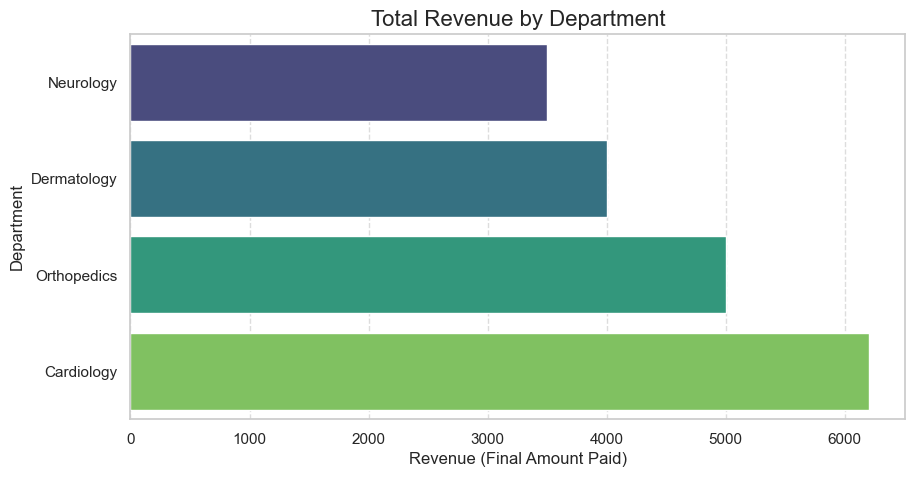

In [13]:
plt.figure(figsize=(10,5))
dept_revenue = final_patients_df.groupby("Department")["FinalAmount"].sum().sort_values()
sns.barplot(x=dept_revenue.values, y=dept_revenue.index, palette="viridis")

plt.title("Total Revenue by Department", fontsize=16)
plt.xlabel("Revenue (Final Amount Paid)")
plt.ylabel("Department")
plt.show()

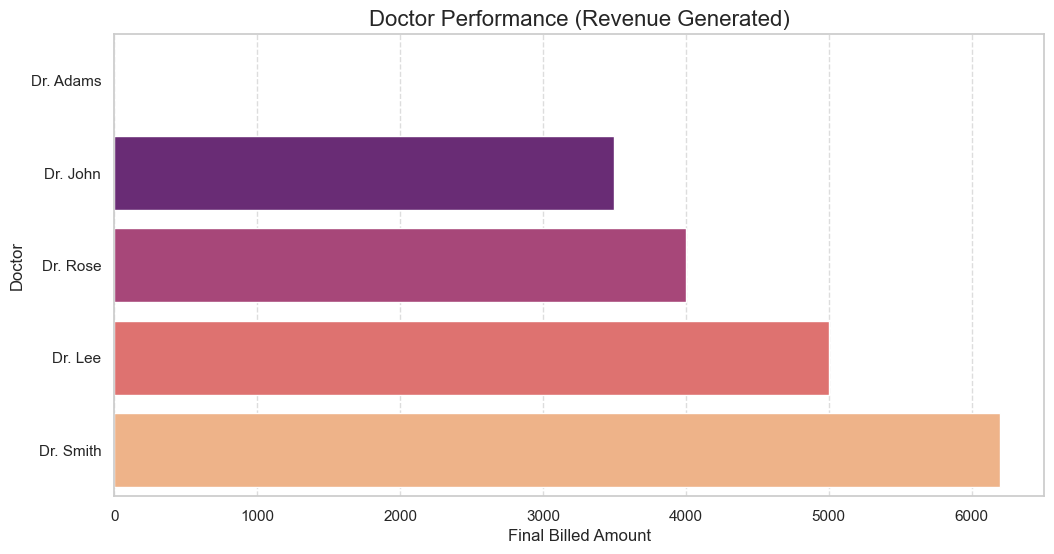

In [14]:
plt.figure(figsize=(12,6))
doctor_revenue = final_patients_df.groupby("Doctor")["FinalAmount"].sum().sort_values()

sns.barplot(x=doctor_revenue.values, y=doctor_revenue.index, palette="magma")

plt.title("Doctor Performance (Revenue Generated)", fontsize=16)
plt.xlabel("Final Billed Amount")
plt.ylabel("Doctor")
plt.show()

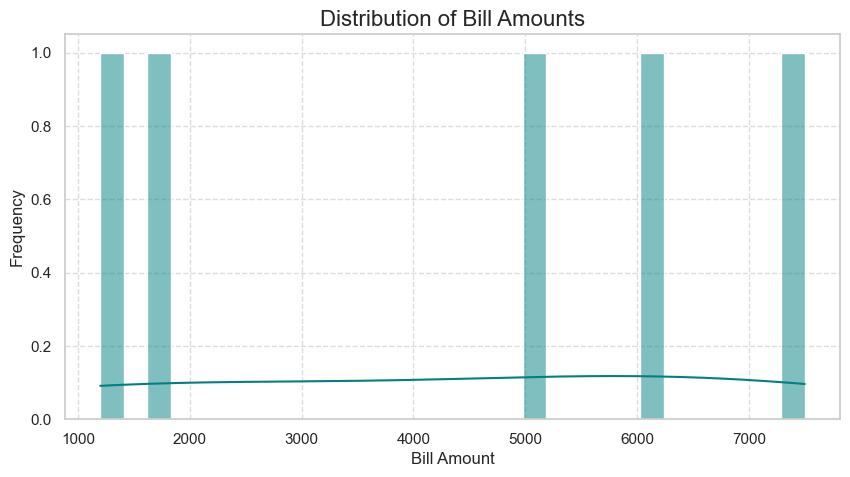

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(final_patients_df["BillAmount"], kde=True, bins=30, color='teal')

plt.title("Distribution of Bill Amounts", fontsize=16)
plt.xlabel("Bill Amount")
plt.ylabel("Frequency")
plt.show()

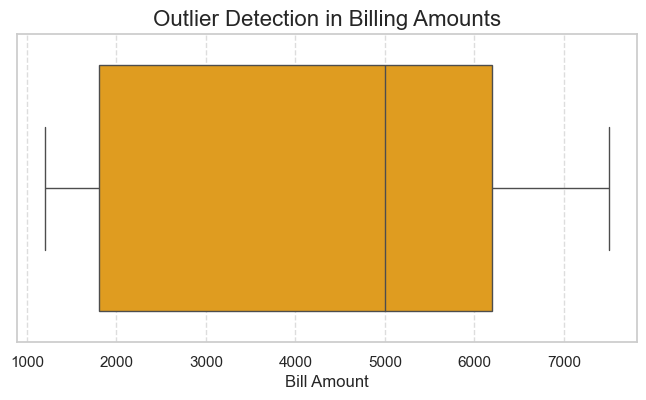

In [16]:
plt.figure(figsize=(8,4))
sns.boxplot(x=final_patients_df["BillAmount"], color='orange')

plt.title("Outlier Detection in Billing Amounts", fontsize=16)
plt.xlabel("Bill Amount")
plt.show()

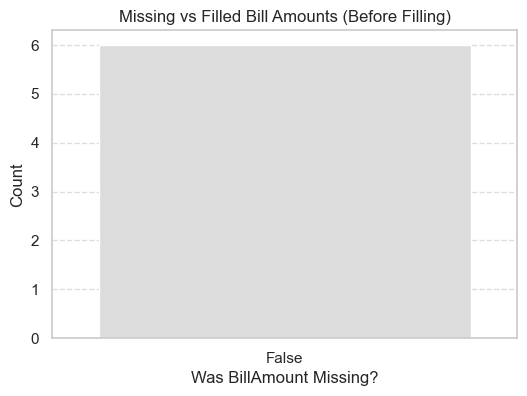

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=patient_billing_df["BillAmount"].isna(),
    palette="coolwarm"
)

plt.title("Missing vs Filled Bill Amounts (Before Filling)")
plt.xlabel("Was BillAmount Missing?")
plt.ylabel("Count")
plt.show()

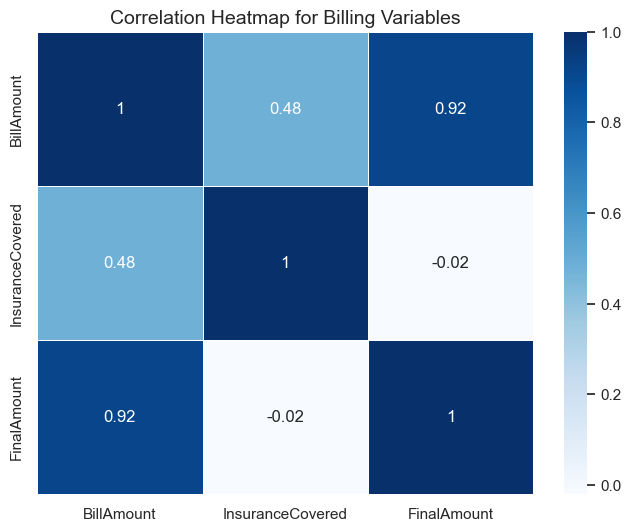

In [18]:
plt.figure(figsize=(8,6))

billing_corr = final_patients_df[["BillAmount","InsuranceCovered","FinalAmount"]].corr()

sns.heatmap(billing_corr, annot=True, cmap="Blues", linewidths=0.5)

plt.title("Correlation Heatmap for Billing Variables", fontsize=14)
plt.show()

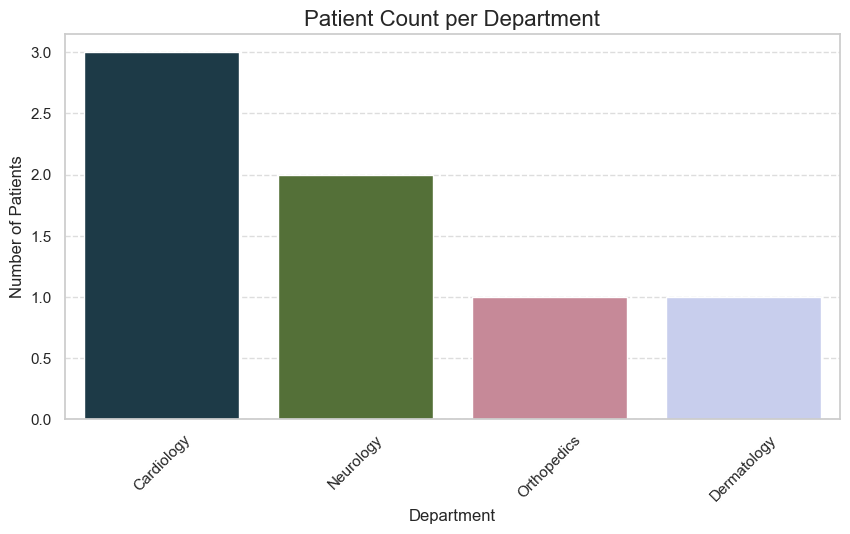

In [19]:
plt.figure(figsize=(10,5))
dept_counts = final_patients_df["Department"].value_counts()

sns.barplot(x=dept_counts.index, y=dept_counts.values, palette="cubehelix")

plt.title("Patient Count per Department", fontsize=16)
plt.xlabel("Department")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()